<a href="https://colab.research.google.com/github/aasimk910/AI-Module/blob/main/Worksheetweek3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###
  # Perform an element wise addition of two input arrays stored in a new array(list):
  # Create a new array to put all the prediction let's name that a state_neuron.
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
  state_neuron = []
  for i in range(len(X1)):
    if X1[i] + X2[i] >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)


  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    state_neuron = []
    for i in range(len(X1)):
      if X1[i] + X2[i] >= T:
        state_neuron.append(1)
      else:
        state_neuron.append(0)

    return state_neuron


In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


The MCP neuron is a simple computational model that works using a threshold-based rule without any learning capability. It takes binary inputs, sums them, and compares the result with a threshold to produce an output. However, it has several limitations: it cannot learn from data, treats all inputs equally (no weights), and cannot solve non-linear problems like XOR. This is because MCP neurons only create linear decision boundaries, which makes them unsuitable for complex real-world problems.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI-ML/Data/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


In this task, the perceptron model is used to classify handwritten digits (0 and 1) from the MNIST dataset. The feature matrix X represents the dataset where each row is an image and each column is a pixel. The weights represent the importance of each pixel in making predictions and are initialized to zero to start learning uniformly. The perceptron computes a weighted sum using np.dot(X, weights) + bias, which determines the predicted class. If the prediction is incorrect, the weights and bias are updated using the perceptron learning rule to reduce error. Final accuracy is important as it shows how well the model performs, and for simple tasks like 0 vs 1, the accuracy is expected to be very high.

### Viewing the Dataset.



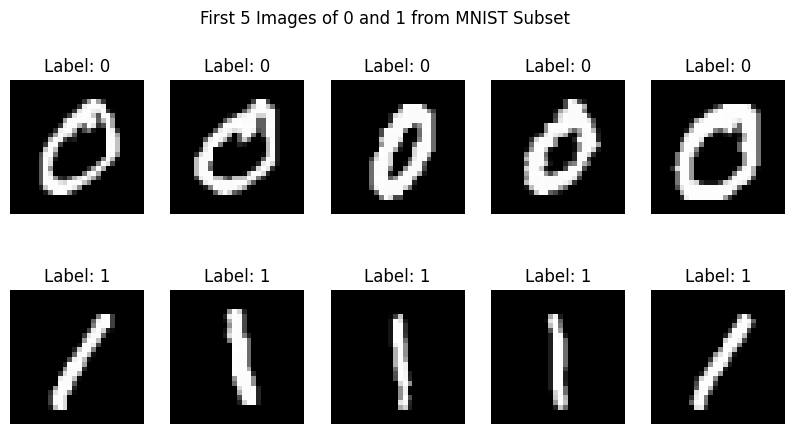

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
        # For each epoch, we iterate through all data points
        for i in range(len(X)):
            # Calculate the predicted output (y_pred)
            # The perceptron's activation function is a step function (0 or 1)
            prediction = np.dot(X[i], weights) + bias
            y_pred = np.where(prediction >= 0, 1, 0)

            # Update weights and bias
            # The update rule is: weight = weight + learning_rate * (true_output - predicted_output) * input
            #                       bias = bias + learning_rate * (true_output - predicted_output)
            weights += learning_rate * (y[i] - y_pred) * X[i]
            bias += learning_rate * (y[i] - y_pred)

        # Calculate accuracy after each epoch
        final_predictions = np.dot(X, weights) + bias
        epoch_y_pred = np.where(final_predictions >= 0, 1, 0)
        accuracy = np.mean(epoch_y_pred == y)

        # Print accuracy every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}: Accuracy = {accuracy:.4f}")


    return weights, bias, accuracy

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.9992
Epoch 20: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 40: Accuracy = 1.0000
Epoch 50: Accuracy = 1.0000
Epoch 60: Accuracy = 1.0000
Epoch 70: Accuracy = 1.0000
Epoch 80: Accuracy = 1.0000
Epoch 90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000
The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images

        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


The variable misclassified_idx stores the indices of incorrectly predicted images. It is used to visualize errors made by the model, helping us understand where the perceptron struggles. If the output shows “All images were correctly classified!”, it means the model achieved perfect accuracy and successfully separated the classes, indicating that the data is linearly separable and well-suited for the perceptron.

# **Task 3: Perceptron Algorithm for 3 vs 5 Classification.**

# Step 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI-ML/Data/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


# Viewing the Dataset.

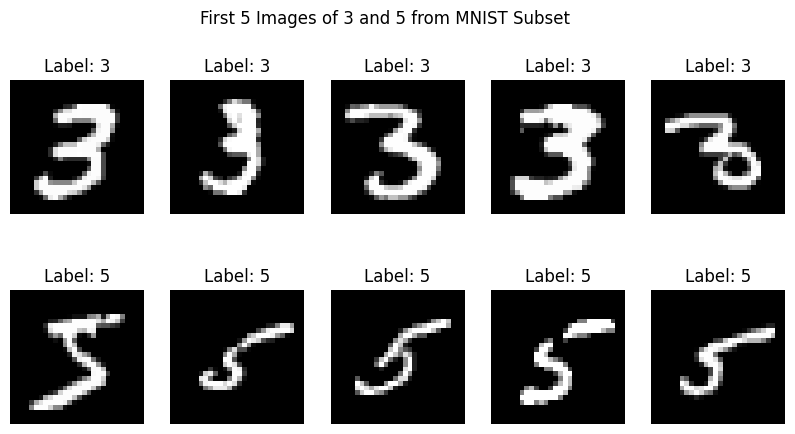

In [ ]:
# Separate images for label 3 and label 5
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print(f"Error: Not enough images (Found {len(images_3)} of '3' and {len(images_5)} of '5') to plot.")
else:
    for i in range(5):
        # Plot digit 3
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap='gray')
        axes[0, i].set_title('Label: 3')
        axes[0, i].axis('off')
        # Plot digit 5
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap='gray')
        axes[1, i].set_title('Label: 5')
        axes[1, i].axis('off')
    plt.suptitle('First 5 Images of 3 and 5 from MNIST Subset')
    plt.show()

# Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

# Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

# Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
        # For each epoch, we iterate through all data points
        for i in range(len(X)):
            # Calculate the predicted output (y_pred)
            # The perceptron's activation function is a step function (0 or 1)
            prediction = np.dot(X[i], weights) + bias
            y_pred = np.where(prediction >= 0, 1, 0)

            # Update weights and bias
            # The update rule is: weight = weight + learning_rate * (true_output - predicted_output) * input
            #                       bias = bias + learning_rate * (true_output - predicted_output)
            weights += learning_rate * (y[i] - y_pred) * X[i]
            bias += learning_rate * (y[i] - y_pred)

        # Calculate accuracy after each epoch
        final_predictions = np.dot(X, weights) + bias
        epoch_y_pred = np.where(final_predictions >= 0, 1, 0)
        accuracy = np.mean(epoch_y_pred == y)

        # Print accuracy every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}: Accuracy = {accuracy:.4f}")


    return weights, bias, accuracy

# Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

Epoch 10: Accuracy = 0.9613
Epoch 20: Accuracy = 0.9540
Epoch 30: Accuracy = 0.9730
Epoch 40: Accuracy = 0.9730
Epoch 50: Accuracy = 0.9518
Epoch 60: Accuracy = 0.9515
Epoch 70: Accuracy = 0.9770
Epoch 80: Accuracy = 0.9861
Epoch 90: Accuracy = 0.9829
Epoch 100: Accuracy = 0.9869
The Final Accuracy is:  0.986866107260124


# Step 5: Visualize Misclassified Images

--- Classification Results ---
Overall Accuracy: 98.69%
Total Misclassified: 36


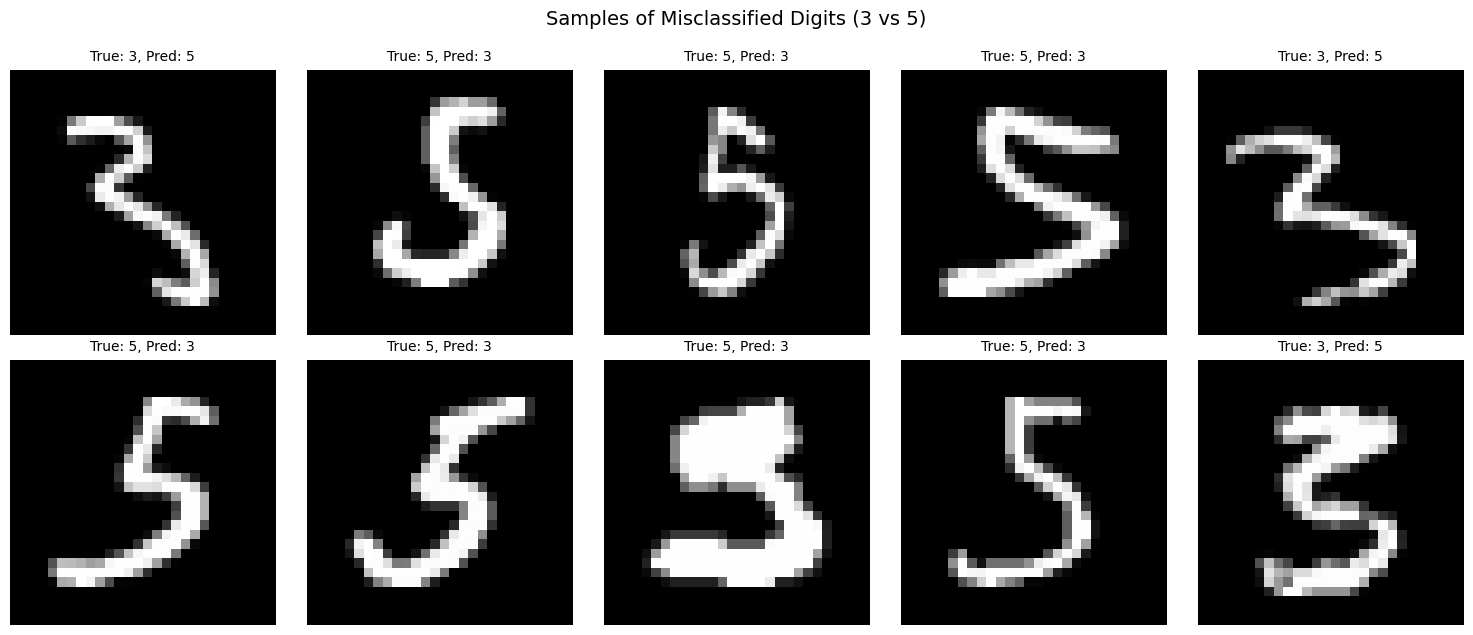

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images

        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

In this task, the perceptron is applied to classify digits 3 and 5, which is a more challenging problem. Since these digits are more visually similar, the model is likely to make more errors. By analyzing misclassified images, we can observe the limitations of the perceptron, as it struggles with complex patterns. This highlights the need for more advanced models like neural networks for better performance in such cases.